In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'], errors='ignore')
    print(f"Dataset successfully loaded! Shape: {df.shape}")
display(df.head())

Saving 1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv to 1776250375-P2-Healthcare Analytics for Doctor Visits (1) (1).csv
Dataset successfully loaded! Shape: (5190, 12)


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [3]:

df.info()


display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   object 
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   object 
 8   freepoor   5190 non-null   object 
 9   freerepat  5190 non-null   object 
 10  nchronic   5190 non-null   object 
 11  lchronic   5190 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 486.7+ KB


,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


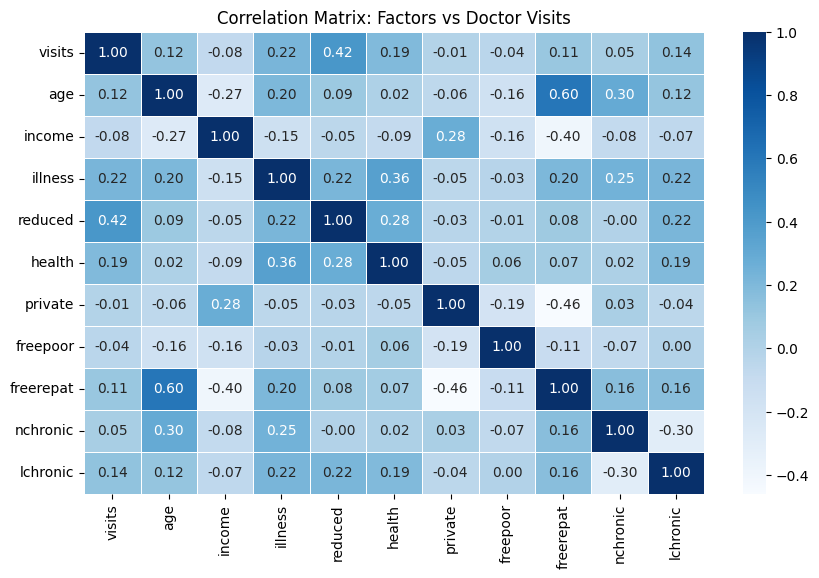

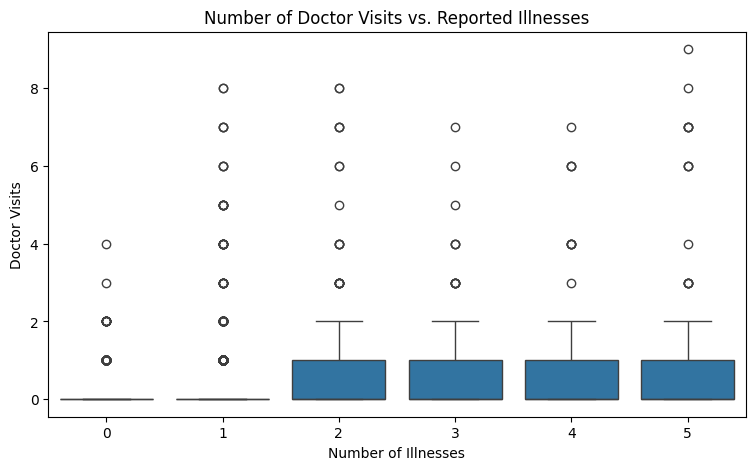

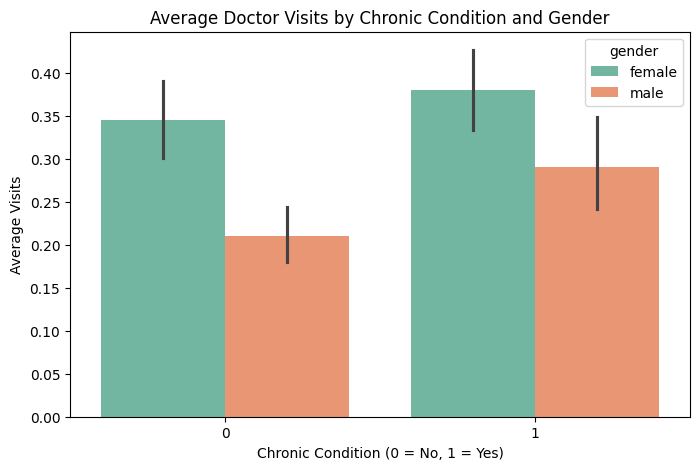

In [4]:

binary_cols = ['private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']
for col in binary_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.lower().map({'yes': 1, 'no': 0})

plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Factors vs Doctor Visits')
plt.show()

# Compare Doctor Visits by Illness Count
plt.figure(figsize=(9, 5))
sns.boxplot(x='illness', y='visits', data=df)
plt.title('Number of Doctor Visits vs. Reported Illnesses')
plt.xlabel('Number of Illnesses')
plt.ylabel('Doctor Visits')
plt.show()


plt.figure(figsize=(8, 5))
sns.barplot(x='nchronic', y='visits', hue='gender', data=df, palette='Set2')
plt.title('Average Doctor Visits by Chronic Condition and Gender')
plt.xlabel('Chronic Condition (0 = No, 1 = Yes)')
plt.ylabel('Average Visits')
plt.show()

In [5]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Drop or fill missing values if any exist
df = df.dropna()  # Or use df.fillna(method='ffill') depending on your needs

Missing values per column:
visits       0
gender       0
age          0
income       0
illness      0
reduced      0
health       0
private      0
freepoor     0
freerepat    0
nchronic     0
lchronic     0
dtype: int64
